# Task 2. Named entity recognition + image classification

In this notebook, we build a multimodal ML pipeline that:
1. Trains an **NER model** to detect animal names in text.
2. Trains an **Image Classification model** to recognize animals in images.
3. Combines both models into a **pipeline** that checks if the user's text matches the content of the image.

## Dataset Setup

We use the **Animals-10 dataset** from Kaggle, which contains 10 animal categories.  
Steps:
- Install Kaggle API
- Download the dataset
- Extract the images

In [1]:
#Imports
import os, random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from utils.download_animals_dataset import download_and_prepare_dataset

from image_model.infer_image import predict_image
from image_model.train_image import image_train_model
from ner_model.train_ner import ner_train_model

In [2]:
# Download and prepare the Animals-10 dataset
# Make sure to place your Kaggle API token in ~/.kaggle/kaggle.json
# You can get the token from https://www.kaggle.com/docs/api
download_and_prepare_dataset()

[+] Kaggle CLI is already installed
[+] Kaggle API configured
[*] Downloading Animals-10 dataset...
[+] Dataset downloaded
[!] Folder animals10 already exists, skipping extraction.
animals10.zip deleted


## Install Dependencies

We install the required libraries:  
- `torch`, `torchvision` - for image classification   
- `PIL` - for image processing  
- `matplotlib`/`pandas` - for data visualization and EDA

## Exploratory Data Analysis

Before training, let us take a quick look at the dataset:
- It contains **10 animal classes**.  
- The dataset is balanced with several thousand images per class.  
- Below we visualize a few random examples from the dataset.

In [2]:
# List classes in the dataset
data_dir = "animals10/raw-img"
classes = os.listdir(data_dir)

print("Classes:", classes)

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


The **Animals-10 dataset** contains 10 animal classes.  
The original labels are in **Italian**, so we map them to **English** for consistency with the NER model.

- scoiattolo → squirrel  
- pecora → sheep  
- cane → dog  
- ragno → spider  
- gallina → chicken  
- mucca → cow  
- gatto → cat  
- cavallo → horse  
- farfalla → butterfly  
- elefante → elephant

In [3]:
# Mapping Italian → English
mapping = {
    "scoiattolo": "squirrel",
    "pecora": "sheep",
    "cane": "dog",
    "ragno": "spider",
    "gallina": "chicken",
    "mucca": "cow",
    "gatto": "cat",
    "cavallo": "horse",
    "farfalla": "butterfly",
    "elefante": "elephant"
}
classes_en = [mapping[c] for c in classes]

print("Original class names (IT):", classes)
print("Mapped class names (EN):", classes_en)

Original class names (IT): ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']
Mapped class names (EN): ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']


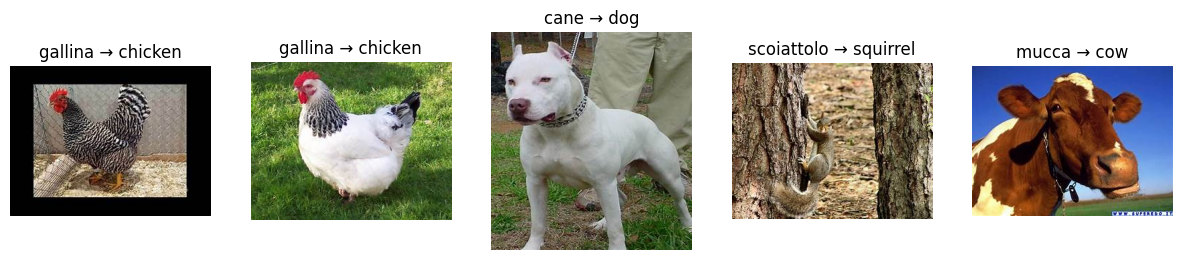

In [4]:
# Show random samples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax in axes:
    cls = random.choice(classes)
    img_path = os.path.join(data_dir, cls,
                            random.choice(os.listdir(os.path.join(data_dir, cls))))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{cls} → {mapping[cls]}")
    ax.axis("off")
plt.show()

## Image Classification with ResNet18

We fine-tune a ResNet18 model on the Animals-10 dataset.  
- Input: images (resized to 128x128).  
- Output: predicted animal class.  
- Model checkpoint saved to `resnet_animals.pth`.

In [5]:
# Train the image classification model
image_train_model()

In [4]:
# Path to a sample image
image_path = Path("animals10/raw-img/cavallo/OIP-0b4F6_zQfANx6SOMUAlWwgHaFw.jpeg")
print(predict_image(image_path))

horse


## Named Entity Recognition (NER)

We fine-tune a transformer-based model (`DistilBERT`) to extract animal names from text.  
- Training data: synthetic sentences mentioning animals.  
- Goal: detect and label animal entities.  
- Output: trained model saved to `ner_model/ner_model_out/`

In [12]:
# Training Named Entity Recognition model
ner_train_model(epochs=1, batch_size=16, max_train_samples=5000)

In [8]:
# Training Named Entity Recognition model via 5 epochs
ner_train_model(epochs=5, batch_size=16, max_train_samples=10000)

In [2]:
from ner_model.infer_ner import get_animals_from_text

Device set to use cpu


In [3]:
print(get_animals_from_text("The butterfly is sitting on a flower."))
print(get_animals_from_text("We saw an horse near the river."))
print(get_animals_from_text("A dog is playing on the field."))

['butterfly']
['horse']
['dog']


## Final Pipeline: Text + Image → Boolean

Pipeline flow:
1. Extract animal entity from the text using NER.  
2. Predict the animal class from the image using ResNet.  
3. Compare both results.  
   - If they match - return `True`  
   - Otherwise - return `False`
4. Below we test the pipeline on different examples.  
For each case we show:
    - The input **text**  
    - The **image**  
    - The final **boolean result** (True/False)

In [4]:
from pipeline.pipeline import show_demo

Device set to use cpu


 Text entities: ['elephant']
 Image prediction: elephant
 Text: There is an elephant on the picture.
 Match result: True


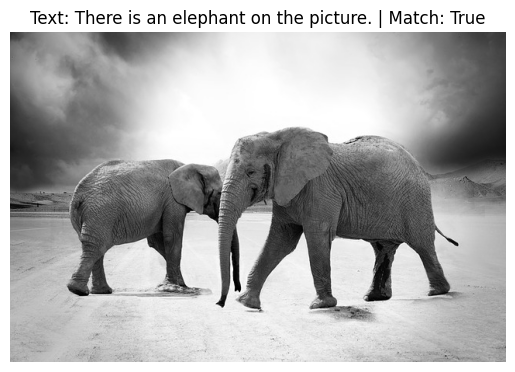

In [5]:
# Run demo cases
show_demo(
    "There is an elephant on the picture.",
    "animals10/raw-img/elefante/e032b10b2df21c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg"
)


 Text entities: ['horse']
 Image prediction: horse
 Text: A horse is sitting on the field.
 Match result: True


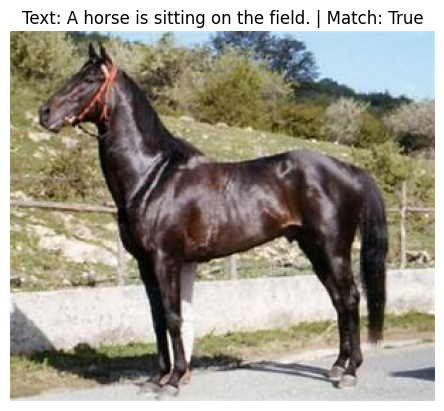

In [6]:
show_demo(
    "A horse is sitting on the field.",
    "animals10/raw-img/cavallo/OIP-0eeBhUnfkVPP7eCiJLmesQHaGc.jpeg"
)

 Text entities: ['cow']
 Image prediction: dog
 Text: It is a cow.
 Match result: False


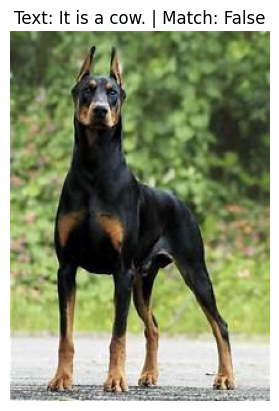

In [7]:
show_demo("It is a cow.", "animals10/raw-img/cane/OIP-0cwqK_pId75Pu0YLQq7HwgHaKj.jpeg")

Test the pipeline with different examples:

- Text: "There is an elephant on the picture."  
- Image: elephant image - **True**

- Text: "A horse is sitting on the field."  
- Image: horse image - **True**

- Text: "It is a cow."  
- Image: dog image - **False**